In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import glob
import tp2_reconstruccion_3d.code_examples.charuco_example.aruco as aruco
import auxiliares
import importlib
import utils_budha_checkerboard as ubc

# Calibracion

In [3]:
# Parámetros del tablero checkerboard
checkerboard = (10, 7)          # número de esquinas internas
square_size_mm = 24.2           # tamaño del cuadrado en milímetros
square_size = square_size_mm / 1000.0  # convertir a metros

# Directiorio base de las imágenes de calibración
base_dir = "tp2_reconstruccion_3d/datasets/stereo_budha_charuco/calib"

# Cargar o calibrar camara estereo
calib_path = os.path.join(base_dir, "stereo_calib.pkl")
if not os.path.exists(calib_path):
    calib = ubc.calibrar_stereo_checkerboard(base_dir, ["left*.jpg", "right*.jpg"], checkerboard, square_size)
else:
    calib= ubc.cargar_calibracion_stereo(calib_path)

Pares válidos: 20
RMS left: 1.0192 | RMS right: 1.0374 | RMS stereo: 1.2477
Guardado: stereo_calibration.pkl


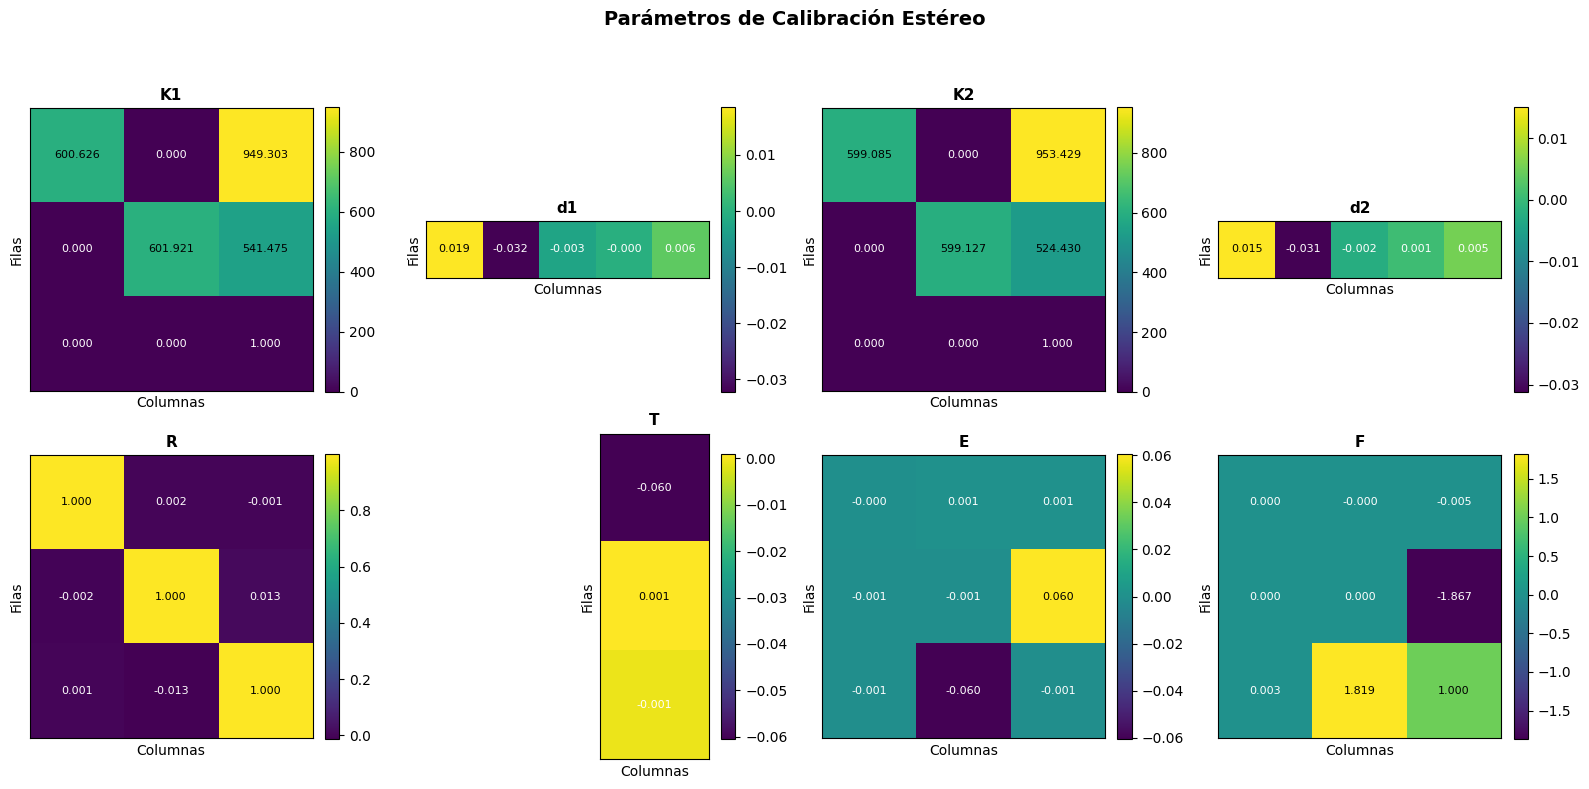

In [4]:
# Visualizar todas las matrices en una cuadrícula 2x4
ubc.graficar_matrices_calibracion(calib)

# Asignar variables principales (sin redefinir ni duplicar)
left_K, left_dist = calib["left_K"], calib["left_dist"]
right_K, right_dist = calib["right_K"], calib["right_dist"]
R, T = calib["R"], calib["T"]

# Rectificacion

✅ Mapas de rectificación guardados en: tp2_reconstruccion_3d/datasets/stereo_budha_charuco/calib/stereo_maps.pkl


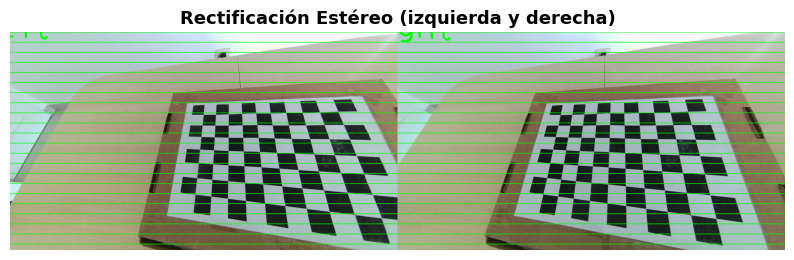

In [5]:
# Tamaño de imagen
image_size = ubc.inferir_image_size(calib, base_dir)

# Calcular la rectificación estéreo
R1, R2, P1, P2, Q, validRoi1, validRoi2 = ubc.calcular_rectificacion(calib, image_size, alpha=0)


# Generar los mapas de rectificación   
left_map_x, left_map_y, right_map_x, right_map_y = ubc.generar_mapas_rectificacion(
    calib, R1, R2, P1, P2, image_size
)

# Guardar los mapas
maps_file = os.path.join(base_dir, "stereo_maps.pkl")

stereo_maps = {
    "left_map_x": left_map_x,
    "left_map_y": left_map_y,
    "right_map_x": right_map_x,
    "right_map_y": right_map_y,
    "R1": R1,
    "R2": R2,
    "P1": P1,
    "P2": P2,
    "Q": Q,
    "validRoi1": validRoi1,
    "validRoi2": validRoi2,
    "image_size": image_size
}

ubc.guardar_stereo_maps(maps_file, stereo_maps)
print("✅ Mapas de rectificación guardados en:", maps_file)

# Visualizar la rectificación estéreo
left_img = sorted(glob.glob(os.path.join(base_dir, "*left*.jpg")))[0]
right_img = sorted(glob.glob(os.path.join(base_dir, "*right*.jpg")))[0]

ubc.visualizar_rectificacion(
    left_img, right_img, left_map_x, left_map_y, right_map_x, right_map_y,
    step=50, title="Rectificación Estéreo (izquierda y derecha)"
)

In [6]:
# Rectificar capturas y guardar ROI común (color)

# Cargar los mapas de rectificación generados en la calibración
maps_path = os.path.join(base_dir, "stereo_maps.pkl")
maps = ubc.cargar_stereo_maps(maps_path)

# Definir carpetas de entrada (capturas crudas) y salida (rectificadas)
captures_dir = "tp2_reconstruccion_3d/datasets/stereo_budha_charuco/captures"
out_roi = os.path.join(captures_dir, "rectificadas")

# Emparejar imágenes izquierda/derecha por nombre o índice
pares = ubc.emparejar_pares(captures_dir)

# Calcular la región común entre ambas cámaras (ROI válida compartida)
roi_comun = ubc.interseccion_rois(maps["validRoi1"], maps["validRoi2"])

# Aplicar la rectificación y guardar cada par recortado en la ROI común
procesados = ubc.rectificar_y_guardar_pares(
    pares,
    maps["left_map_x"], maps["left_map_y"],
    maps["right_map_x"], maps["right_map_y"],
    roi_comun, out_roi,
    indice_inicial=1, interpolacion=cv2.INTER_LINEAR
)

# Confirmar resultados
print("Rectificación de capturas completada.")
print("Directorio de salida:", out_roi)
print("Pares procesados:", procesados)


Rectificación de capturas completada.
Directorio de salida: tp2_reconstruccion_3d/datasets/stereo_budha_charuco/captures/rectificadas
Pares procesados: 21


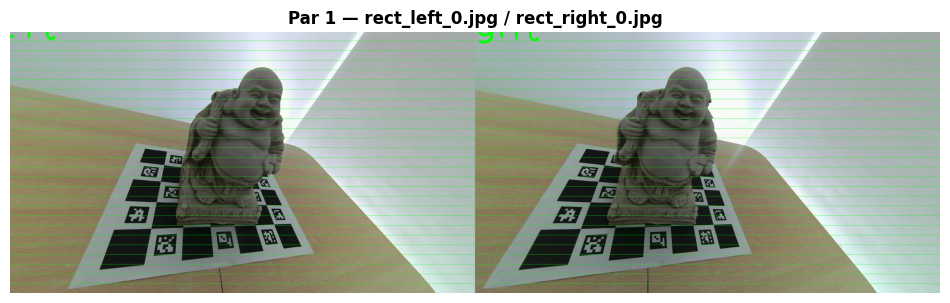

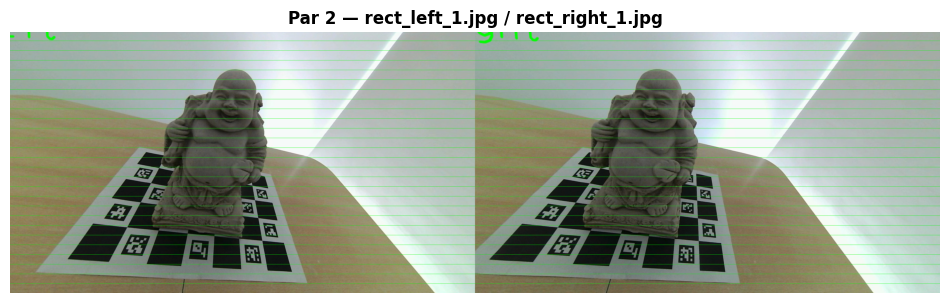

In [7]:
# Visualizar algunas imágenes rectificadas con líneas epipolares
ubc.visualizar_imagenes_rectificadas(
    path_rectificadas="tp2_reconstruccion_3d/datasets/stereo_budha_charuco/captures/rectificadas",
    step=40, n_mostrar=2
)

# Calculo de los mapas de disparidad

Se noto en los ejemplos de la muñeca y el del budha con el checkerboard que el mejor mapa de disparidad obtenido fue mediante CREStereo de la libreria de Stereodemo. Es por eso que solo se usa ese metodo para hacer el calculo del mapa de disparidad. 

In [8]:
# Paths de entrada y salida
path_imgs = "tp2_reconstruccion_3d/datasets/stereo_budha_charuco/captures/rectificadas"
out_dir   = "tp2_reconstruccion_3d/datasets/stereo_budha_charuco/captures"

# Calcular disparidad con stereodemo
ubc.calcular_disparidad_stereodemo(path_imgs, out_dir, metodo="cre")

Imágenes encontradas: 21 pares
Método seleccionado: CRE


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:121: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Resultados guardados en: tp2_reconstruccion_3d/datasets/stereo_budha_charuco/captures/disparidad_cre


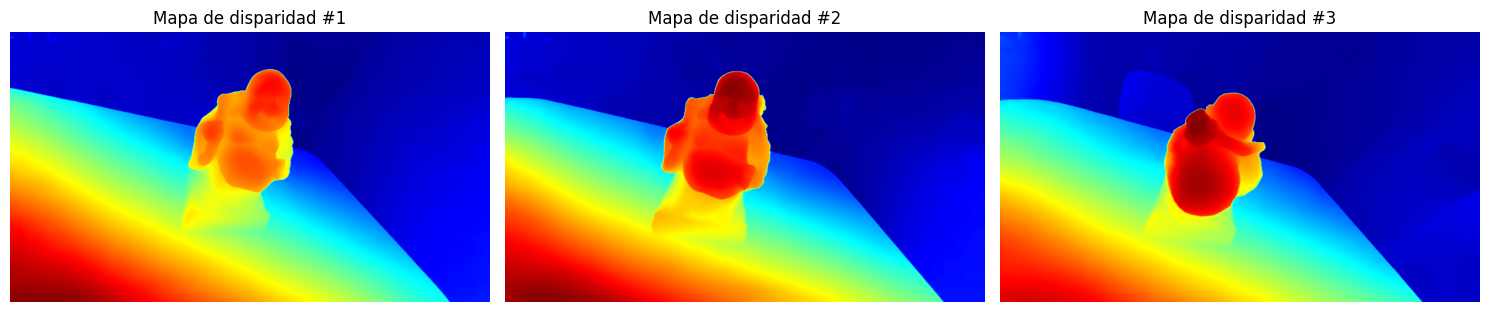

In [9]:
# Carpeta con los mapas de disparidad
path_disparidad = "tp2_reconstruccion_3d/datasets/stereo_budha_charuco/captures/disparidad_cre"

# Buscar mapas
disp_imgs = sorted(glob.glob(os.path.join(path_disparidad, "disp_color_*.png")))

# Mostrar algunos ejemplos
n = 3
fig, axes = plt.subplots(1, n, figsize=(15, 5))
for i in range(n):
    disp = cv2.imread(disp_imgs[i])
    disp_rgb = cv2.cvtColor(disp, cv2.COLOR_BGR2RGB)
    axes[i].imshow(disp_rgb)
    axes[i].set_title(f"Mapa de disparidad #{i+1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

# Reconstruccion 3D

In [10]:
# Configuración del Charuco Board
DICTIONARY_TYPE = cv2.aruco.DICT_6X6_250
SQUARES_X = 5
SQUARES_Y = 7
SQUARE_LENGTH = 52.6  # mm
MARKER_LENGTH = 31.3  # mm

# Crear diccionario y board de Charuco
aruco_dict = cv2.aruco.getPredefinedDictionary(DICTIONARY_TYPE)
charuco_board = cv2.aruco.CharucoBoard(
    (SQUARES_X, SQUARES_Y),
    SQUARE_LENGTH / 1000.0,  # convertir a metros
    MARKER_LENGTH / 1000.0,  # convertir a metros
    aruco_dict
)


ANÁLISIS DE CALIDAD DE DETECCIÓN DE CHARUCO

Imagen          Estado     Marcadores   Posición (x, y, z)
--------------------------------------------------------------------------------
left_0.jpg      OK         7            (0.099, 0.023, 0.530)
left_1.jpg      OK         7            (0.100, 0.055, 0.497)
left_10.jpg     OK         9            (-0.250, 0.139, 0.205)
left_11.jpg     OK         7            (-0.368, 0.062, 0.295)
left_12.jpg     OK         8            (-0.396, 0.014, 0.430)
left_13.jpg     OK         7            (-0.359, -0.030, 0.448)
left_14.jpg     OK         7            (-0.392, -0.057, 0.528)
left_15.jpg     OK         6            (-0.316, -0.056, 0.639)
left_16.jpg     OK         7            (-0.249, -0.054, 0.677)
left_17.jpg     OK         7            (-0.176, -0.043, 0.650)
left_18.jpg     OK         8            (-0.101, 0.001, 0.596)
left_19.jpg     OK         7            (0.056, 0.053, 0.544)
left_2.jpg      OK         8            (0.100, 0.090, 0

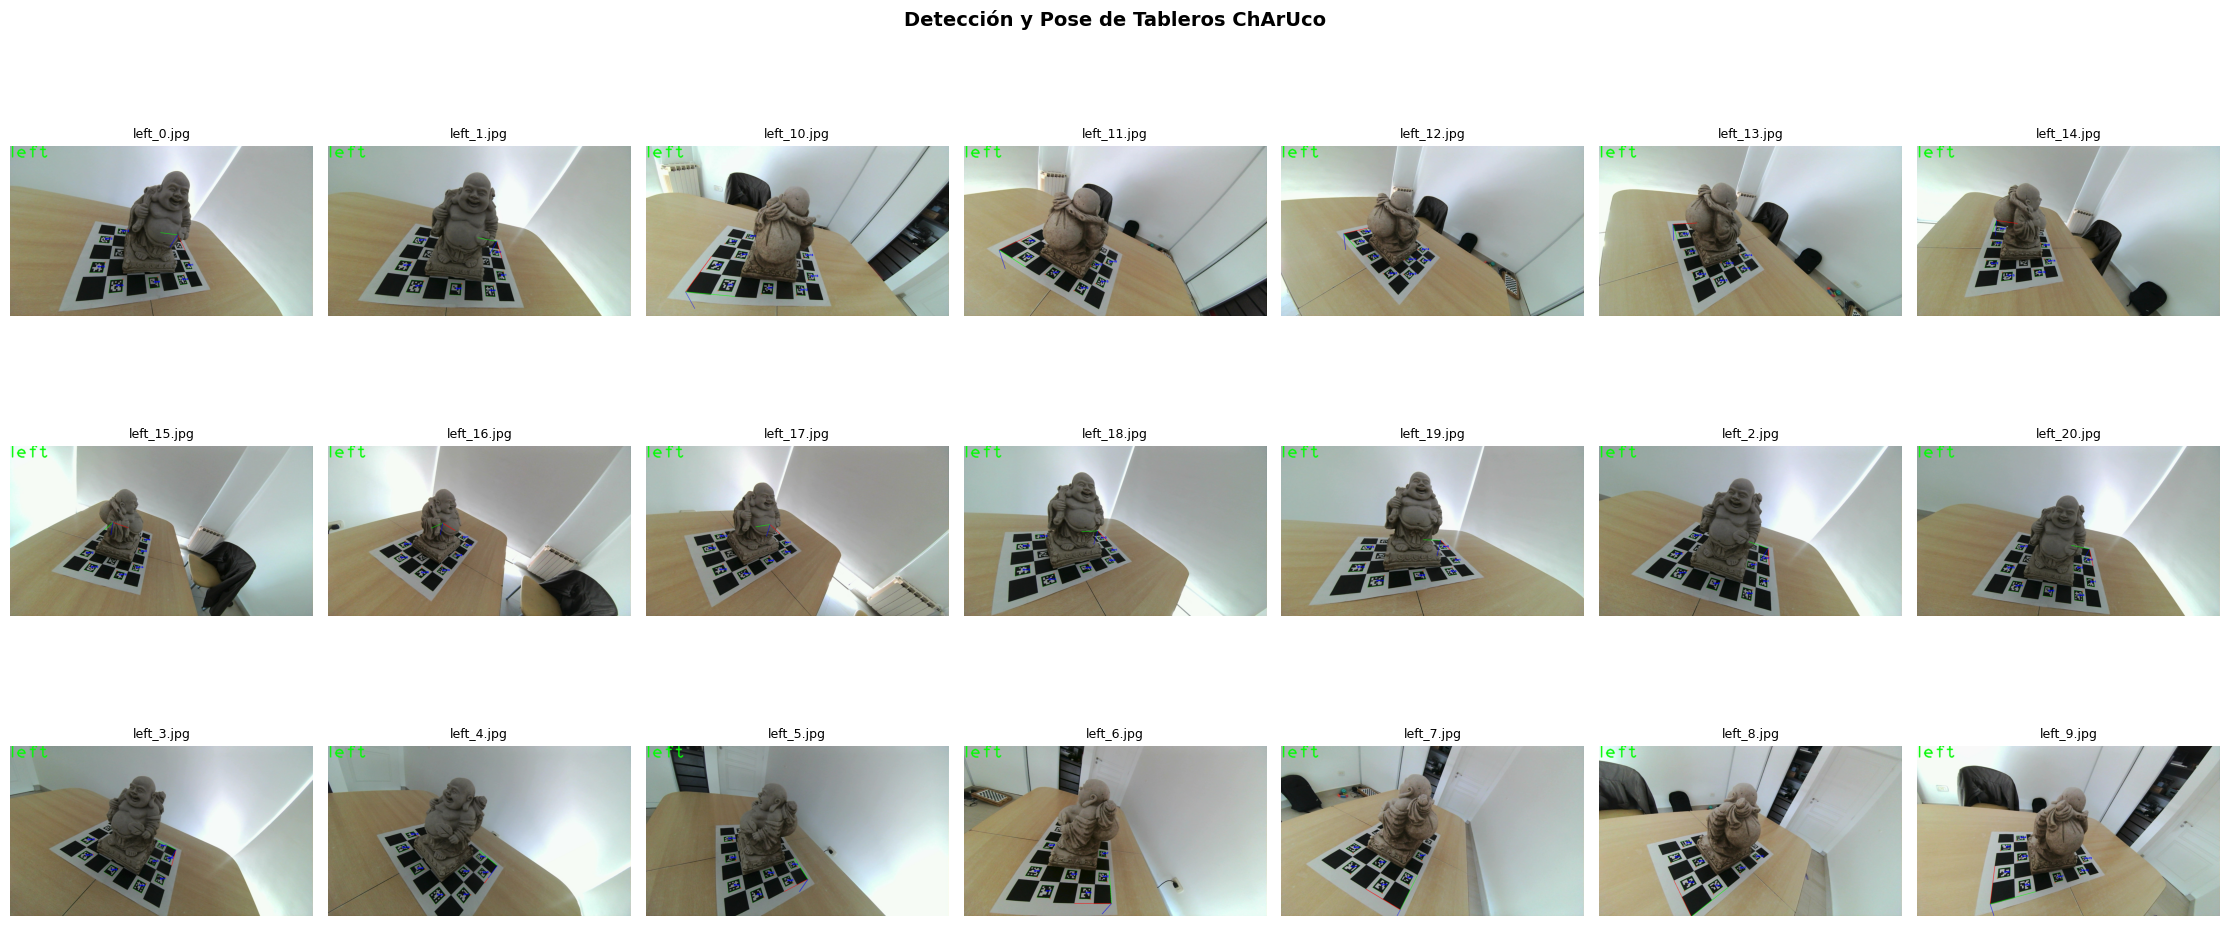

In [11]:
# Analizar las poses de las detecciones en las imagenes rectificadas
resultados_deteccion = ubc.analizar_calidad_detecciones(
    visualizar=True,
    charuco_board=charuco_board,
    square_length=SQUARE_LENGTH,
    max_visualizaciones=21
)

In [12]:
# Calcular y visualizar nube de puntos para distintas configuraciones

import open3d as o3d

# CONFIGURACIÓN 1: 3 imágenes, con planos de fondo
pc_1 = ubc.reconstruccion_3d_charuco(
    max_distance=1.0,
    voxel_size=0.002,
    max_images=3,
    min_markers=6,
    filtrar_planos=False,  # Ver todo incluyendo fondo
    charuco_board=charuco_board
)

# CONFIGURACIÓN 2: 3 imágenes, sin planos
pc_2 = ubc.reconstruccion_3d_charuco(
    max_distance=1.0,
    voxel_size=0.002,
    max_images=3,
    min_markers=6,
    filtrar_planos=True,  # Eliminar planos grandes
    charuco_board=charuco_board
)

# CONFIGURACIÓN 3: Todas las imágenes, con planos de fondo
pc_3 = ubc.reconstruccion_3d_charuco(
    max_distance=1.0,
    voxel_size=0.001,
    max_images=None,  # Todas
    min_markers=6,
    filtrar_planos=False,
    charuco_board=charuco_board
)

# CONFIGURACIÓN 4: Todas las imágenes, sin planos
pc_4 = ubc.reconstruccion_3d_charuco(
    max_distance=1.0,
    voxel_size=0.001,
    max_images=None,  # Todas
    min_markers=6,
    filtrar_planos=True, # Eliminar planos grandes
    charuco_board=charuco_board
)



Iniciando reconstrucción 3D con 3 imágenes...


Reconstrucción completada: 3 imágenes válidas.
Guardado: tp2_reconstruccion_3d/datasets/stereo_budha_charuco/reconstruccion_alineada_3imgs.ply

Iniciando reconstrucción 3D con 3 imágenes...


Reconstrucción completada: 3 imágenes válidas.
Guardado: tp2_reconstruccion_3d/datasets/stereo_budha_charuco/reconstruccion_alineada_3imgs.ply

Iniciando reconstrucción 3D con 21 imágenes...


Reconstrucción completada: 21 imágenes válidas.
Guardado: tp2_reconstruccion_3d/datasets/stereo_budha_charuco/reconstruccion_alineada_21imgs.ply

Iniciando reconstrucción 3D con 21 imágenes...


Reconstrucción completada: 21 imágenes válidas.
Guardado: tp2_reconstruccion_3d/datasets/stereo_budha_charuco/reconstruccion_alineada_21imgs.ply


In [13]:
# CONFIGURACIÓN 2: Bounding box
# Calcular la altura sobre el tablero
h = ubc.altura_sobre_tablero(pc_2)

if h is not None:
    print(f"Altura total sobre el tablero: {h:.3f} m")

# Rango en el eje z
bbox_range_z = (h / 2) + 0.1   # un poco más de la mitad de la altura total

print(f"→ bbox_range_z = {bbox_range_z:.3f} ")

# Aplicar bounding box ajustado
nube_buda_1, bbox = ubc.filtrar_buda_bbox(
    pc_2,
    square_size_m=0.0526,   # tamaño real del cuadrado en metros
    bbox_range_z=bbox_range_z,
    margin=0,
    auto_centrar=True
)
o3d.visualization.draw_geometries([nube_buda_1, bbox])

# CONFIGURACIÓN 4: Bounding box
# Calcular la altura sobre el tablero
h = ubc.altura_sobre_tablero(pc_4)

if h is not None:
    print(f"Altura total sobre el tablero: {h:.3f} m")

# Rango en el eje z
bbox_range_z = (h / 2) + 0.085   # un poco más de la mitad de la altura total

print(f"→ bbox_range_z = {bbox_range_z:.3f} m, margin = {0:.3f} m")

# Aplicar bounding box ajustado
nube_buda_2, bbox = ubc.filtrar_buda_bbox(
    pc_4,
    square_size_m=0.0526,   # tamaño real del cuadrado en metros
    bbox_range_z=bbox_range_z,
    margin=0,
    auto_centrar=True
)
o3d.visualization.draw_geometries([nube_buda_2, bbox])


Altura total sobre el tablero: 0.308 m
→ bbox_range_z = 0.254 
Dimensiones del tablero: 526.0 x 368.2 mm
Rango Z: ±254.0 mm
Margen XY: 0.0 mm

Rango actual de la nube:
  X: [-163.1, 459.3] mm
  Y: [-250.2, 629.7] mm
  Z: [-278.0, 30.0] mm

Centro detectado: [148.1, 189.8] mm

Bounding Box:
  Min: [-114.9, 5.7, -532.0] mm
  Max: [411.1, 373.9, -24.0] mm
Altura total sobre el tablero: 0.311 m
→ bbox_range_z = 0.241 m, margin = 0.000 m
Dimensiones del tablero: 526.0 x 368.2 mm
Rango Z: ±240.6 mm
Margen XY: 0.0 mm

Rango actual de la nube:
  X: [-206.2, 492.3] mm
  Y: [-326.4, 749.5] mm
  Z: [-280.1, 31.2] mm

Centro detectado: [143.0, 211.6] mm

Bounding Box:
  Min: [-120.0, 27.5, -520.7] mm
  Max: [406.0, 395.7, -39.4] mm


## Estimar la altura del buda

In [14]:
# Altura buda = medir la distancia en Z de la nube de puntos filtrada
rz = ubc.rango_eje(nube_buda_1, 'z')
print("Reconstruccion 3 imagenes")
print(f"    La altura del Buda es: {None if rz is None else np.round(rz[2]*100, 3)} cm")

rz = ubc.rango_eje(nube_buda_2, 'z')
print("Reconstruccion todas las imagenes")
print(f"    La altura del Buda es: {None if rz is None else np.round(rz[2]*100, 3)} cm")

Reconstruccion 3 imagenes
    La altura del Buda es: 25.401 cm
Reconstruccion todas las imagenes
    La altura del Buda es: 24.064 cm
